# tqtorch vs FAISS — Benchmark

Compare TurboQuant (scalar quantization via random rotation + Lloyd-Max)
against FAISS Product Quantization, IVF+PQ, and Scalar Quantization.

**Metrics**: Recall@1, Recall@10, index time, search time, memory.

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import time, sys, importlib

# Ensure the package is importable
from tqtorch.search.index import TurboQuantIndex
import faiss

print(f"torch  {torch.__version__}")
print(f"faiss  {faiss.__version__}")
print(f"tqtorch loaded ✓")

torch  2.11.0+cpu
faiss  1.13.2
tqtorch loaded ✓


## 1 · Generate Synthetic Data

In [16]:
N_DB      = 10_000
N_QUERIES = 200
DIM       = 128
K         = 10
SEED      = 42

np.random.seed(SEED)
db_raw      = np.random.randn(N_DB, DIM).astype(np.float32)
queries_raw = np.random.randn(N_QUERIES, DIM).astype(np.float32)

print(f"Database  : {db_raw.shape}")
print(f"Queries   : {queries_raw.shape}")

Database  : (10000, 128)
Queries   : (200, 128)


## 2 · Ground Truth (FAISS Flat IP)

In [17]:
db_gt, q_gt = db_raw.copy(), queries_raw.copy()
faiss.normalize_L2(db_gt)
faiss.normalize_L2(q_gt)

flat = faiss.IndexFlatIP(DIM)
flat.add(db_gt)
gt_scores, gt_ids = flat.search(q_gt, K)
print(f"Ground truth computed — top-1 scores range: [{gt_scores[:,0].min():.3f}, {gt_scores[:,0].max():.3f}]")

Ground truth computed — top-1 scores range: [0.282, 0.424]


## 3 · Helper: Recall@k

In [18]:
def recall_at_k(gt, pred, k):
    return np.mean([gt[i, 0] in pred[i, :k] for i in range(gt.shape[0])])

## 4 · Run Benchmarks

In [19]:
results = []  # (name, add_ms, search_ms, mem_mb, r1, r10)


def faiss_total_memory_mb(index):
    """Get actual memory usage of a FAISS index via serialization."""
    writer = faiss.VectorIOWriter()
    faiss.write_index(index, writer)
    return len(faiss.vector_to_array(writer.data)) / 1e6


def tq_total_memory_mb(idx):
    """Get TQ memory: per-vector storage + shared structures (rotation, QJL, codebook)."""
    per_vec = idx.memory_usage_mb  # packed indices + norms + signs + gammas
    # Shared: rotation matrix Pi (d×d float32)
    shared = idx.dim * idx.dim * 4 / 1e6
    # If IP mode: also QJL projection matrix S (d×d float32)
    if idx.metric == 'ip':
        shared += idx.dim * idx.dim * 4 / 1e6
    # Codebook: negligible (cached, ~few KB), but count it
    shared += 0.001  # ~1KB for codebook
    return per_vec + shared


# ── TurboQuant at various bit widths ──────────────────────────────────────
for bits in [2, 3, 4, 5]:
    db_c = db_raw.copy(); q_c = queries_raw.copy()
    db_c /= np.linalg.norm(db_c, axis=1, keepdims=True) + 1e-12
    q_c  /= np.linalg.norm(q_c,  axis=1, keepdims=True) + 1e-12

    t0 = time.perf_counter()
    idx = TurboQuantIndex(dim=DIM, bits=bits, metric='ip', seed=SEED)
    idx.add(torch.from_numpy(db_c))
    add_ms = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    sc, ids = idx.search(torch.from_numpy(q_c), k=K)
    search_ms = (time.perf_counter() - t0) * 1000
    ids_np = ids.numpy()

    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    mem = tq_total_memory_mb(idx)
    results.append((f'TQ-{bits}bit', add_ms, search_ms, mem, r1, r10))

# ── FAISS PQ ──────────────────────────────────────────────────────────────
for m in [8, 16, 32]:
    db_c = db_raw.copy(); q_c = queries_raw.copy()
    faiss.normalize_L2(db_c); faiss.normalize_L2(q_c)
    index = faiss.IndexPQ(DIM, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db_c); index.add(db_c)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    sc, ids_np = index.search(q_c, K)
    search_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    mem = faiss_total_memory_mb(index)
    results.append((f'PQ(m={m})', add_ms, search_ms, mem, r1, r10))

# ── FAISS IVF+PQ ─────────────────────────────────────────────────────────
for m in [8, 16]:
    db_c = db_raw.copy(); q_c = queries_raw.copy()
    faiss.normalize_L2(db_c); faiss.normalize_L2(q_c)
    nlist = max(4, int(np.sqrt(N_DB)))
    quantizer = faiss.IndexFlatIP(DIM)
    index = faiss.IndexIVFPQ(quantizer, DIM, nlist, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db_c); index.add(db_c)
    add_ms = (time.perf_counter() - t0) * 1000
    index.nprobe = min(16, nlist)
    t0 = time.perf_counter()
    sc, ids_np = index.search(q_c, K)
    search_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    mem = faiss_total_memory_mb(index)
    results.append((f'IVF+PQ(m={m})', add_ms, search_ms, mem, r1, r10))

# ── FAISS SQ ──────────────────────────────────────────────────────────────
for sq_bits, sq_type in [(4, faiss.ScalarQuantizer.QT_4bit), (8, faiss.ScalarQuantizer.QT_8bit)]:
    db_c = db_raw.copy(); q_c = queries_raw.copy()
    faiss.normalize_L2(db_c); faiss.normalize_L2(q_c)
    index = faiss.IndexScalarQuantizer(DIM, sq_type, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db_c); index.add(db_c)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    sc, ids_np = index.search(q_c, K)
    search_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    mem = faiss_total_memory_mb(index)
    results.append((f'SQ({sq_bits}bit)', add_ms, search_ms, mem, r1, r10))

print(f"{'Method':<20} {'Add(ms)':>8} {'Search(ms)':>11} {'Mem(MB)':>8} {'R@1':>6} {'R@10':>6}")
print('-'*65)
for name, a, s, m, r1, r10 in results:
    print(f"{name:<20} {a:>8.1f} {s:>11.1f} {m:>8.2f} {r1:>6.3f} {r10:>6.3f}")

print("\nNote: Memory includes ALL storage — per-vector data + shared structures")
print(f"      TQ shared overhead: rotation({DIM}×{DIM}×4={DIM*DIM*4/1024:.0f}KB) + QJL({DIM*DIM*4/1024:.0f}KB)")
print(f"      FAISS memory: via serialization (includes codebooks, stats, metadata)")

Method                Add(ms)  Search(ms)  Mem(MB)    R@1   R@10
-----------------------------------------------------------------
TQ-2bit                 337.3       141.1     0.49  0.160  0.450
TQ-3bit                 176.6       135.8     0.65  0.365  0.820
TQ-4bit                 185.7       138.0     0.81  0.565  0.975
TQ-5bit                 168.2       118.8     0.97  0.730  0.995
PQ(m=8)                 663.8         7.9     0.21  0.050  0.205
PQ(m=16)                513.4        10.5     0.29  0.200  0.585
PQ(m=32)                709.8        20.6     0.45  0.400  0.935
IVF+PQ(m=8)             562.4         4.2     0.34  0.035  0.130
IVF+PQ(m=16)            872.7         4.9     0.42  0.100  0.385
SQ(4bit)                  8.3        51.3     0.64  0.665  1.000
SQ(8bit)                  6.6        28.4     1.28  0.985  1.000

Note: Memory includes ALL storage — per-vector data + shared structures
      TQ shared overhead: rotation(128×128×4=64KB) + QJL(64KB)
      FAISS memory

## 4a · Pure Brute-Force Comparison (Same Search, Different Compression)

The benchmark above mixes **compression quality** with **search implementation** —
FAISS uses SIMD-optimized C++ while TurboQuant uses Python/PyTorch.

Below we isolate just the **quantization quality**: both methods decompress to float32,
then use the exact same `torch.matmul` brute-force search. This answers:
> "At the same compression level, which quantizer preserves neighbor ranking better?"

Same brute-force search (torch.matmul → topk) for ALL methods
Method                Compress(ms)  Search(ms)  B/vec    R@1   R@10
----------------------------------------------------------------------
Flat (no quant)                0.0        28.6    512  1.000  1.000
TQ-IP-3bit                   164.6        10.1     52  0.385  0.855
TQ-IP-4bit                   128.2         7.3     68  0.615  0.995
TQ-IP-5bit                   113.1        14.2     84  0.775  1.000
TQ-MSE-3bit                   66.0         8.2     50  0.615  0.995
TQ-MSE-4bit                   53.9         7.9     66  0.775  1.000
TQ-MSE-5bit                   48.9         8.9     82  0.885  1.000
FAISS-SQ-4bit                  8.0        15.5     64  0.665  1.000
FAISS-SQ-8bit                  8.1        13.2    128  0.985  1.000
FAISS-PQ(m=16)               400.2        12.4     16  0.200  0.585
FAISS-PQ(m=32)               701.5        10.6     32  0.400  0.935


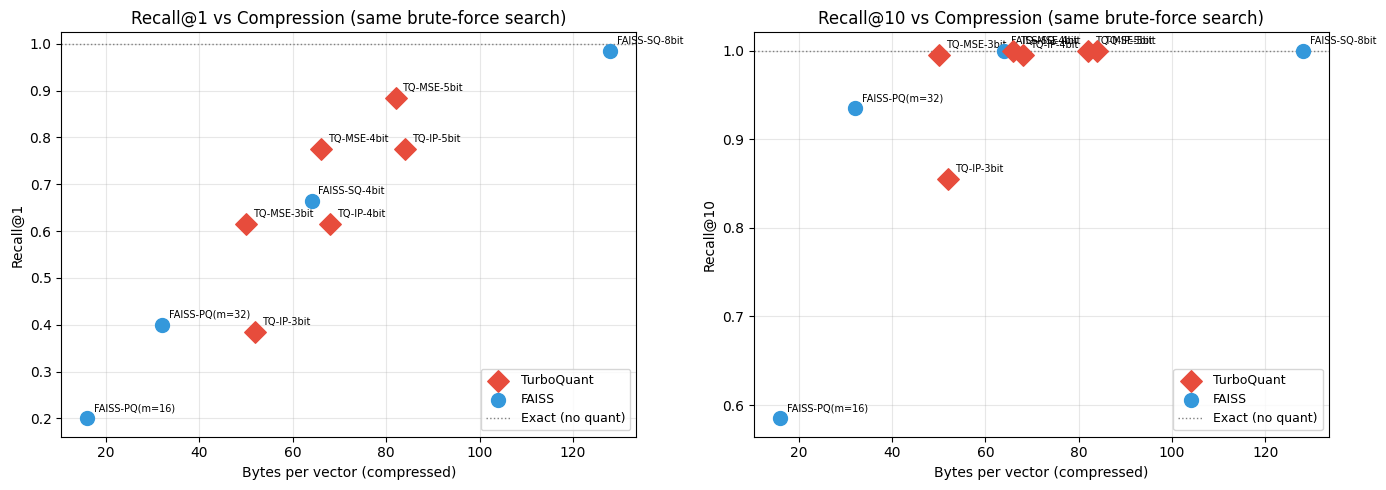

In [20]:
# ── Unified brute-force: decompress → torch.matmul → topk ────────────────
db_n = db_raw.copy(); q_n = queries_raw.copy()
db_n /= np.linalg.norm(db_n, axis=1, keepdims=True) + 1e-12
q_n  /= np.linalg.norm(q_n,  axis=1, keepdims=True) + 1e-12
queries_t = torch.from_numpy(q_n)

def brute_force_search(db_recon: torch.Tensor, queries: torch.Tensor, k: int):
    """Same brute-force for everyone: matmul → topk."""
    scores = queries @ db_recon.T  # (nq, n)
    topk_scores, topk_ids = scores.topk(k, dim=1, largest=True, sorted=True)
    return topk_scores, topk_ids

bf_results = []  # (name, compress_ms, search_ms, mem_bytes_per_vec, r1, r10)

# ── Ground truth: no compression ─────────────────────────────────────────
db_t = torch.from_numpy(db_n)
t0 = time.perf_counter()
_, bf_gt_ids = brute_force_search(db_t, queries_t, K)
gt_search_ms = (time.perf_counter() - t0) * 1000
bf_results.append(('Flat (no quant)', 0, gt_search_ms, DIM * 4, 1.0, 1.0))

# ── TurboQuant IP (Algo 2) ───────────────────────────────────────────────
from tqtorch.core.prod_quantizer import InnerProductQuantizer
for bits in [3, 4, 5]:
    ipq = InnerProductQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt = ipq.quantize(torch.from_numpy(db_n))
    compress_ms = (time.perf_counter() - t0) * 1000
    db_recon = ipq.dequantize(qt)

    t0 = time.perf_counter()
    _, ids = brute_force_search(db_recon, queries_t, K)
    search_ms = (time.perf_counter() - t0) * 1000
    ids_np = ids.numpy()
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    bf_results.append((f'TQ-IP-{bits}bit', compress_ms, search_ms, ipq.bytes_per_vector(), r1, r10))

# ── TurboQuant MSE (Algo 1) ──────────────────────────────────────────────
from tqtorch.core.mse_quantizer import MSEQuantizer
for bits in [3, 4, 5]:
    mq = MSEQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt = mq.quantize(torch.from_numpy(db_n))
    compress_ms = (time.perf_counter() - t0) * 1000
    db_recon = mq.dequantize(qt)

    t0 = time.perf_counter()
    _, ids = brute_force_search(db_recon, queries_t, K)
    search_ms = (time.perf_counter() - t0) * 1000
    ids_np = ids.numpy()
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    bf_results.append((f'TQ-MSE-{bits}bit', compress_ms, search_ms, mq.bytes_per_vector(), r1, r10))

# ── FAISS SQ: decompress via IndexRefineFlat or reconstruct ──────────────
for sq_bits, sq_type in [(4, faiss.ScalarQuantizer.QT_4bit), (8, faiss.ScalarQuantizer.QT_8bit)]:
    db_c = db_raw.copy()
    faiss.normalize_L2(db_c)
    index = faiss.IndexScalarQuantizer(DIM, sq_type, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db_c); index.add(db_c)
    compress_ms = (time.perf_counter() - t0) * 1000
    # Reconstruct all vectors from FAISS compressed storage
    db_recon_np = np.zeros((N_DB, DIM), dtype=np.float32)
    for i in range(N_DB):
        index.reconstruct(i, db_recon_np[i])
    db_recon = torch.from_numpy(db_recon_np)

    t0 = time.perf_counter()
    _, ids = brute_force_search(db_recon, queries_t, K)
    search_ms = (time.perf_counter() - t0) * 1000
    ids_np = ids.numpy()
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    bpv = DIM // 2 if sq_bits == 4 else DIM
    bf_results.append((f'FAISS-SQ-{sq_bits}bit', compress_ms, search_ms, bpv, r1, r10))

# ── FAISS PQ: reconstruct and brute-force ─────────────────────────────────
for m in [16, 32]:
    db_c = db_raw.copy()
    faiss.normalize_L2(db_c)
    index = faiss.IndexPQ(DIM, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db_c); index.add(db_c)
    compress_ms = (time.perf_counter() - t0) * 1000
    db_recon_np = np.zeros((N_DB, DIM), dtype=np.float32)
    for i in range(N_DB):
        index.reconstruct(i, db_recon_np[i])
    db_recon = torch.from_numpy(db_recon_np)

    t0 = time.perf_counter()
    _, ids = brute_force_search(db_recon, queries_t, K)
    search_ms = (time.perf_counter() - t0) * 1000
    ids_np = ids.numpy()
    r1  = recall_at_k(gt_ids, ids_np, 1)
    r10 = recall_at_k(gt_ids, ids_np, K)
    bf_results.append((f'FAISS-PQ(m={m})', compress_ms, search_ms, m, r1, r10))

# ── Print results ─────────────────────────────────────────────────────────
print("Same brute-force search (torch.matmul → topk) for ALL methods")
print(f"{'Method':<20} {'Compress(ms)':>13} {'Search(ms)':>11} {'B/vec':>6} {'R@1':>6} {'R@10':>6}")
print('-' * 70)
for name, c, s, bpv, r1, r10 in bf_results:
    print(f"{name:<20} {c:>13.1f} {s:>11.1f} {bpv:>6} {r1:>6.3f} {r10:>6.3f}")

# ── Plot: recall vs bytes/vector ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

tq_bf = [r for r in bf_results if r[0].startswith('TQ')]
faiss_bf = [r for r in bf_results if r[0].startswith('FAISS')]
flat_bf = [r for r in bf_results if r[0].startswith('Flat')]

for ax, mi, label in [(ax1, 4, 'Recall@1'), (ax2, 5, 'Recall@10')]:
    ax.scatter([r[3] for r in tq_bf], [r[mi] for r in tq_bf],
              s=120, marker='D', color='#e74c3c', zorder=5, label='TurboQuant')
    ax.scatter([r[3] for r in faiss_bf], [r[mi] for r in faiss_bf],
              s=100, marker='o', color='#3498db', zorder=4, label='FAISS')
    if flat_bf:
        ax.axhline(y=1.0, color='gray', ls=':', lw=1, label='Exact (no quant)')
    for r in bf_results[1:]:  # skip Flat
        ax.annotate(r[0], (r[3], r[mi]), fontsize=7,
                    textcoords='offset points', xytext=(5, 5))
    ax.set_xlabel('Bytes per vector (compressed)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Compression (same brute-force search)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('brute_force_comparison.png', dpi=150)
plt.show()

## 4aa · tqtorch vs pyturboquant (Reference Implementation)

Head-to-head comparison of our library against Jörg Bahlmann's `pyturboquant` —
the reference production implementation from the LinkedIn post.

Both implement the same TurboQuant paper. We use the same brute-force search
(decompress → `torch.matmul → topk`) to isolate differences in:
- **Quantization quality** (MSE, recall)
- **Memory layout** (bytes per vector)
- **Compression speed**

pyturboquant  0.1.1
tqtorch   loaded ✓
  QUANTIZER-LEVEL: same brute-force search (torch.matmul → topk)
Method                     Compress(ms)  Search(ms)  B/vec      MSE    R@1   R@10
-------------------------------------------------------------------------------------
tqtorch MSE-3b                 74.8        13.3     50  0.03400  0.615  0.995
pyturboquant MSE-3b                93.4        13.2     52  0.03400  0.615  0.995
tqtorch MSE-4b                 57.5         8.9     66  0.00932  0.775  1.000
pyturboquant MSE-4b                97.1        17.7     68  0.00932  0.775  1.000
tqtorch MSE-5b                101.6         8.1     82  0.00245  0.885  1.000
pyturboquant MSE-5b               121.8        18.2     84  0.00311  0.885  1.000
tqtorch IP-3b                 128.5        15.3     52  0.11590  0.385  0.855
pyturboquant IP-3b                130.6        19.4     56  0.11590  0.385  0.855
tqtorch IP-4b                 167.6         8.6     68  0.03400  0.615  0.995
pyturboqua

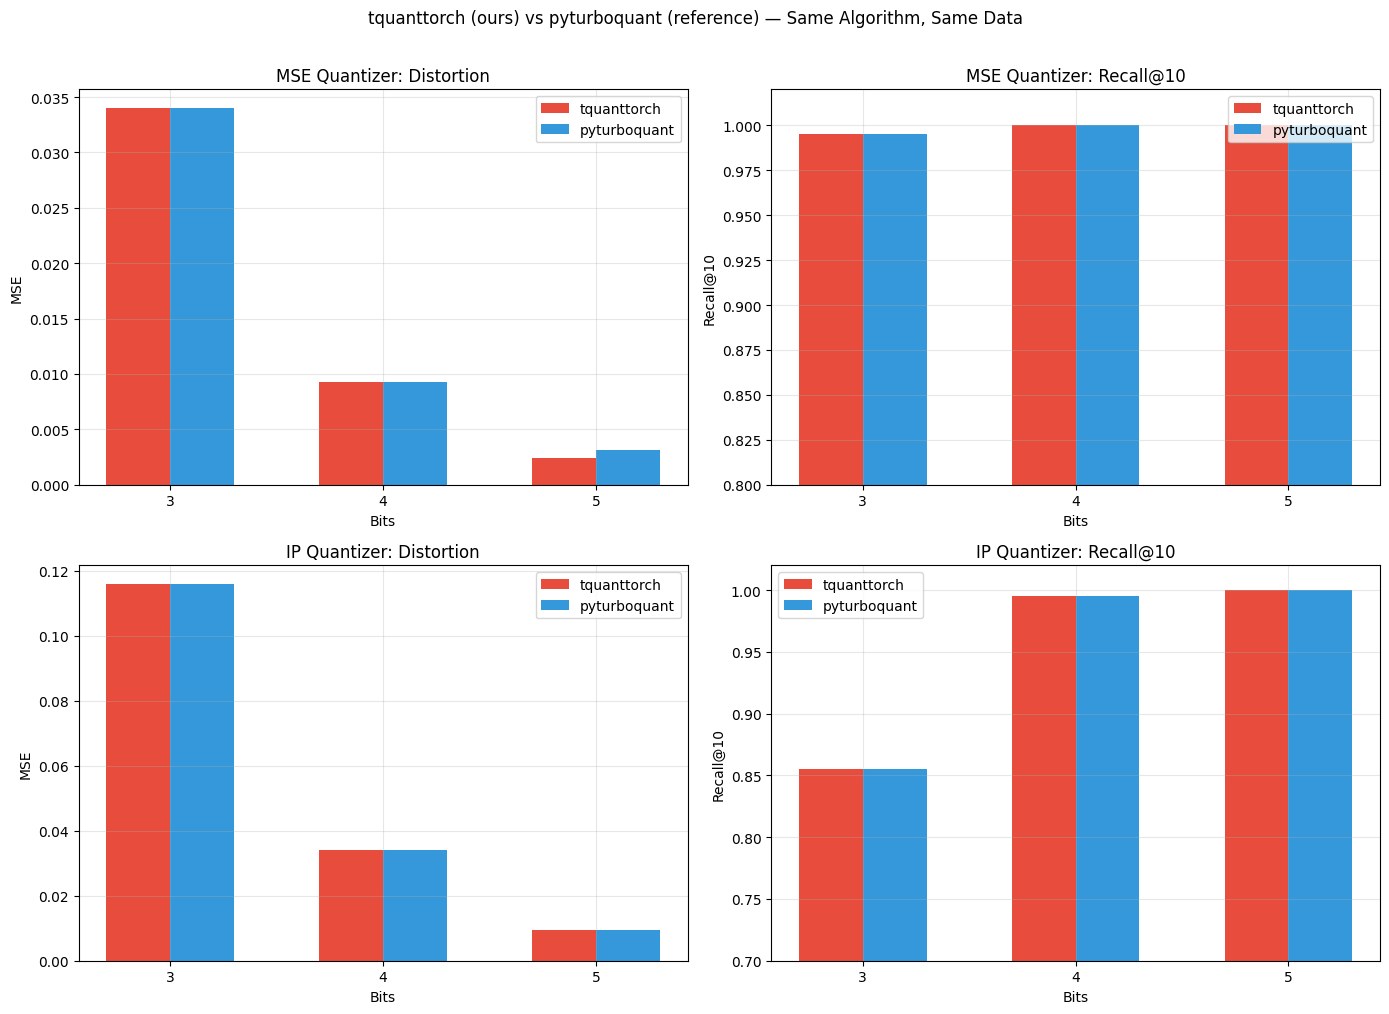

In [21]:
# ── tqtorch vs pyturboquant — same brute-force search ─────────────────
import pyturboquant
from pyturboquant.core import MSEQuantizer as PTQ_MSEQuantizer, InnerProductQuantizer as PTQ_IPQuantizer
from pyturboquant.search import TurboQuantIndex as PTQ_TurboQuantIndex

from tqtorch.core.mse_quantizer import MSEQuantizer as TQT_MSEQuantizer
from tqtorch.core.prod_quantizer import InnerProductQuantizer as TQT_IPQuantizer
from tqtorch.search.index import TurboQuantIndex as TQT_TurboQuantIndex

print(f"pyturboquant  {pyturboquant.__version__}")
print(f"tqtorch   loaded ✓")

db_n = db_raw.copy(); q_n = queries_raw.copy()
db_n /= np.linalg.norm(db_n, axis=1, keepdims=True) + 1e-12
q_n  /= np.linalg.norm(q_n,  axis=1, keepdims=True) + 1e-12
db_t = torch.from_numpy(db_n)
q_t  = torch.from_numpy(q_n)

def brute_force_search(db_recon, queries, k):
    scores = queries @ db_recon.T
    return scores.topk(k, dim=1, largest=True, sorted=True)

# pyturboquant doesn't expose bytes_per_vector(); compute from their formula
def ptq_bpv_mse(dim, bits):
    return dim * bits // 8 + 4   # packed + float32 norm
def ptq_bpv_ip(dim, bits):
    return dim * bits // 8 + 8   # packed + float32 norm + float32 gamma

cmp_results = []  # (name, compress_ms, search_ms, bpv, mse, r1, r10)

# ── MSE quantizer comparison ─────────────────────────────────────────────
for bits in [3, 4, 5]:
    # --- tqtorch (ours) ---
    q_ours = TQT_MSEQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt_ours = q_ours.quantize(db_t)
    c_ms_ours = (time.perf_counter() - t0) * 1000
    recon_ours = q_ours.dequantize(qt_ours)
    mse_ours = ((db_t - recon_ours) ** 2).sum(dim=1).mean().item()
    t0 = time.perf_counter()
    _, ids = brute_force_search(recon_ours, q_t, K)
    s_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    cmp_results.append((f'tqtorch MSE-{bits}b', c_ms_ours, s_ms, q_ours.bytes_per_vector(), mse_ours, r1, r10))

    # --- pyturboquant (reference) ---
    q_ref = PTQ_MSEQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt_ref = q_ref.quantize(db_t)
    c_ms_ref = (time.perf_counter() - t0) * 1000
    recon_ref = q_ref.dequantize(qt_ref)
    mse_ref = ((db_t - recon_ref) ** 2).sum(dim=1).mean().item()
    t0 = time.perf_counter()
    _, ids = brute_force_search(recon_ref, q_t, K)
    s_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    cmp_results.append((f'pyturboquant MSE-{bits}b', c_ms_ref, s_ms, ptq_bpv_mse(DIM, bits), mse_ref, r1, r10))

# ── IP quantizer comparison ──────────────────────────────────────────────
for bits in [3, 4, 5]:
    # --- tqtorch (ours) ---
    q_ours = TQT_IPQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt_ours = q_ours.quantize(db_t)
    c_ms_ours = (time.perf_counter() - t0) * 1000
    recon_ours = q_ours.dequantize(qt_ours)
    mse_ours = ((db_t - recon_ours) ** 2).sum(dim=1).mean().item()
    t0 = time.perf_counter()
    _, ids = brute_force_search(recon_ours, q_t, K)
    s_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    cmp_results.append((f'tqtorch IP-{bits}b', c_ms_ours, s_ms, q_ours.bytes_per_vector(), mse_ours, r1, r10))

    # --- pyturboquant (reference) ---
    q_ref = PTQ_IPQuantizer(DIM, bits, seed=SEED)
    t0 = time.perf_counter()
    qt_ref = q_ref.quantize(db_t)
    c_ms_ref = (time.perf_counter() - t0) * 1000
    recon_ref = q_ref.dequantize(qt_ref)
    mse_ref = ((db_t - recon_ref) ** 2).sum(dim=1).mean().item()
    t0 = time.perf_counter()
    _, ids = brute_force_search(recon_ref, q_t, K)
    s_ms = (time.perf_counter() - t0) * 1000
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    cmp_results.append((f'pyturboquant IP-{bits}b', c_ms_ref, s_ms, ptq_bpv_ip(DIM, bits), mse_ref, r1, r10))

# ── Index-level comparison ────────────────────────────────────────────────
# pyturboquant uses metric='l2' (not 'mse') and 'ip'
metric_map_ours = {'mse': 'mse', 'ip': 'ip'}
metric_map_ref  = {'mse': 'l2',  'ip': 'ip'}

idx_results = []
for bits in [3, 4, 5]:
    for metric_key in ['mse', 'ip']:
        # tqtorch
        idx_ours = TQT_TurboQuantIndex(dim=DIM, bits=bits, metric=metric_map_ours[metric_key], seed=SEED)
        t0 = time.perf_counter()
        idx_ours.add(db_t)
        add_ours = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        _, ids_ours = idx_ours.search(q_t, k=K)
        srch_ours = (time.perf_counter() - t0) * 1000
        r1_o  = recall_at_k(gt_ids, ids_ours.numpy(), 1)
        r10_o = recall_at_k(gt_ids, ids_ours.numpy(), K)

        # pyturboquant
        idx_ref = PTQ_TurboQuantIndex(dim=DIM, bits=bits, metric=metric_map_ref[metric_key], seed=SEED)
        t0 = time.perf_counter()
        idx_ref.add(db_t)
        add_ref = (time.perf_counter() - t0) * 1000
        t0 = time.perf_counter()
        _, ids_ref = idx_ref.search(q_t, k=K)
        srch_ref = (time.perf_counter() - t0) * 1000
        r1_r  = recall_at_k(gt_ids, ids_ref.numpy(), 1)
        r10_r = recall_at_k(gt_ids, ids_ref.numpy(), K)

        idx_results.append((bits, metric_key, add_ours, srch_ours, idx_ours.memory_usage_mb,
                            r1_o, r10_o, add_ref, srch_ref, idx_ref.memory_usage_mb, r1_r, r10_r))

# ── Print quantizer-level results ─────────────────────────────────────────
print("=" * 85)
print("  QUANTIZER-LEVEL: same brute-force search (torch.matmul → topk)")
print("=" * 85)
print(f"{'Method':<25} {'Compress(ms)':>13} {'Search(ms)':>11} {'B/vec':>6} {'MSE':>8} {'R@1':>6} {'R@10':>6}")
print('-' * 85)
for name, c, s, bpv, mse, r1, r10 in cmp_results:
    print(f"{name:<25} {c:>13.1f} {s:>11.1f} {bpv:>6} {mse:>8.5f} {r1:>6.3f} {r10:>6.3f}")

# ── Print index-level results ─────────────────────────────────────────────
print("\n" + "=" * 95)
print("  INDEX-LEVEL: each library's built-in .add() / .search()")
print("=" * 95)
print(f"{'Bits':>4} {'Metric':>6}  {'Add(ours)':>10} {'Srch(ours)':>11} {'Mem(ours)':>10} {'R@10(o)':>8}"
      f"  {'Add(ref)':>9} {'Srch(ref)':>10} {'Mem(ref)':>9} {'R@10(r)':>8}")
print('-' * 95)
for b, met, ao, so, mo, r1o, r10o, ar, sr, mr, r1r, r10r in idx_results:
    print(f"{b:>4} {met:>6}  {ao:>10.1f} {so:>11.1f} {mo:>10.3f} {r10o:>8.3f}"
          f"  {ar:>9.1f} {sr:>10.1f} {mr:>9.3f} {r10r:>8.3f}")

# ── Plot: MSE and Recall side-by-side ─────────────────────────────────────
ours_mse = [r for r in cmp_results if r[0].startswith('tqtorch MSE')]
ref_mse  = [r for r in cmp_results if r[0].startswith('pyturboquant MSE')]
ours_ip  = [r for r in cmp_results if r[0].startswith('tqtorch IP')]
ref_ip   = [r for r in cmp_results if r[0].startswith('pyturboquant IP')]

bits_list = [3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MSE distortion
ax = axes[0, 0]
ax.bar([b - 0.15 for b in bits_list], [r[4] for r in ours_mse], 0.3, color='#e74c3c', label='tqtorch')
ax.bar([b + 0.15 for b in bits_list], [r[4] for r in ref_mse],  0.3, color='#3498db', label='pyturboquant')
ax.set_xlabel('Bits'); ax.set_ylabel('MSE'); ax.set_title('MSE Quantizer: Distortion')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(bits_list)

# MSE recall
ax = axes[0, 1]
ax.bar([b - 0.15 for b in bits_list], [r[6] for r in ours_mse], 0.3, color='#e74c3c', label='tqtorch')
ax.bar([b + 0.15 for b in bits_list], [r[6] for r in ref_mse],  0.3, color='#3498db', label='pyturboquant')
ax.set_xlabel('Bits'); ax.set_ylabel('Recall@10'); ax.set_title('MSE Quantizer: Recall@10')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(bits_list); ax.set_ylim(0.8, 1.02)

# IP distortion
ax = axes[1, 0]
ax.bar([b - 0.15 for b in bits_list], [r[4] for r in ours_ip], 0.3, color='#e74c3c', label='tqtorch')
ax.bar([b + 0.15 for b in bits_list], [r[4] for r in ref_ip],  0.3, color='#3498db', label='pyturboquant')
ax.set_xlabel('Bits'); ax.set_ylabel('MSE'); ax.set_title('IP Quantizer: Distortion')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(bits_list)

# IP recall
ax = axes[1, 1]
ax.bar([b - 0.15 for b in bits_list], [r[6] for r in ours_ip], 0.3, color='#e74c3c', label='tqtorch')
ax.bar([b + 0.15 for b in bits_list], [r[6] for r in ref_ip],  0.3, color='#3498db', label='pyturboquant')
ax.set_xlabel('Bits'); ax.set_ylabel('Recall@10'); ax.set_title('IP Quantizer: Recall@10')
ax.legend(); ax.grid(alpha=0.3); ax.set_xticks(bits_list); ax.set_ylim(0.7, 1.02)

plt.suptitle('tqtorch (ours) vs pyturboquant (reference) — Same Algorithm, Same Data', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('tqtorch_vs_pyturboquant.png', dpi=150)
plt.show()

## 4b · MSE vs Shannon — Where the "~2.7x" Comes From

The paper's "~2.7x of Shannon" is about **reconstruction MSE**, not recall.
- Shannon lower bound: $\text{MSE} \geq 1/4^b$ (no quantizer can beat this)
- TurboQuant upper bound: $\text{MSE} \leq \frac{3\pi}{2} \cdot 1/4^b \approx 4.7/4^b$
- In practice the ratio is **~1.5–2.3x** — even better than the theoretical 4.7x

Below we measure empirical MSE with **Algorithm 1 (MSE-only, full b bits)** and compare to the bound.
Then we show why low MSE ≠ high recall: ranking requires **relative ordering** preservation, not just low absolute error.

Bits   Shannon LB   TQ Empirical   Ratio
------------------------------------------
   1      0.25000        0.35890    1.44x
   2      0.06250        0.11601    1.86x
   3      0.01562        0.03421    2.19x
   4      0.00391        0.00922    2.36x
   5      0.00098        0.00247    2.53x
   6      0.00024        0.00067    2.73x


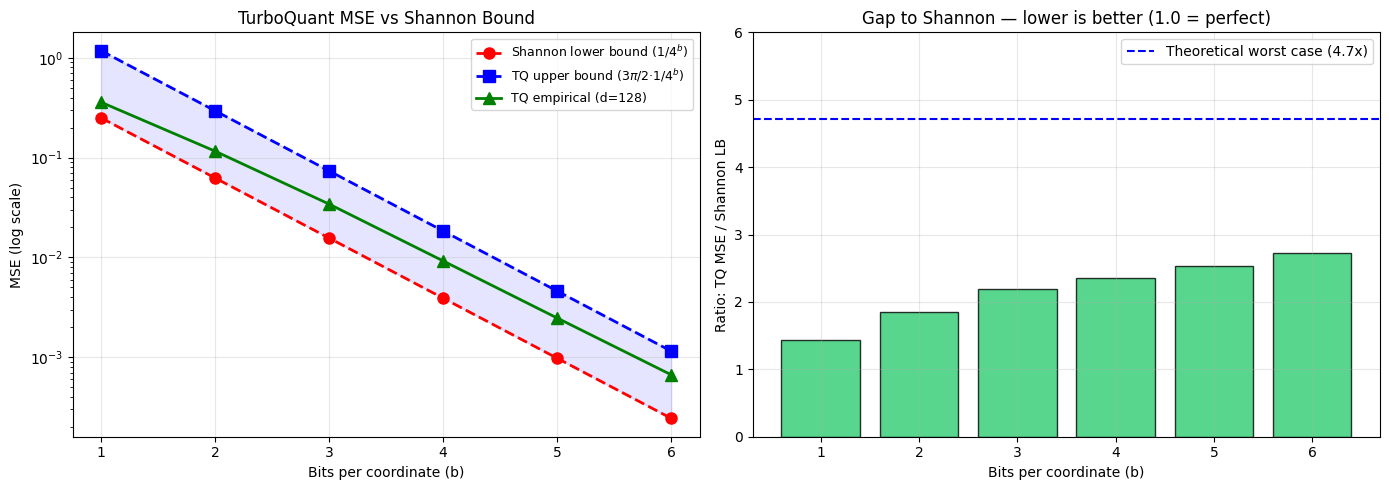

In [22]:
from tqtorch.core.mse_quantizer import MSEQuantizer

# ── Empirical MSE vs Shannon lower bound ──────────────────────────────────
bit_widths = list(range(1, 7))
lower_bound = [1 / 4**b for b in bit_widths]
upper_bound = [3 * np.pi / 2 / 4**b for b in bit_widths]

n_trials = 500
empirical_mse = []
for b in bit_widths:
    q = MSEQuantizer(DIM, b, seed=SEED)
    x = torch.randn(n_trials, DIM)
    x = x / x.norm(dim=1, keepdim=True)
    qt = q.quantize(x)
    x_hat = q.dequantize(qt)
    mse = ((x - x_hat) ** 2).sum(dim=1).mean().item()
    empirical_mse.append(mse)

# ── Print the ratio table ─────────────────────────────────────────────────
print(f"{'Bits':>4}  {'Shannon LB':>11}  {'TQ Empirical':>13}  {'Ratio':>6}")
print("-" * 42)
for b, lb, emp in zip(bit_widths, lower_bound, empirical_mse):
    print(f"{b:>4}  {lb:>11.5f}  {emp:>13.5f}  {emp/lb:>6.2f}x")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(bit_widths, lower_bound, 'r--o', lw=2, ms=8, label='Shannon lower bound ($1/4^b$)')
ax1.semilogy(bit_widths, upper_bound, 'b--s', lw=2, ms=8, label='TQ upper bound ($3π/2 · 1/4^b$)')
ax1.semilogy(bit_widths, empirical_mse, 'g-^', lw=2, ms=8, label=f'TQ empirical (d={DIM})')
ax1.fill_between(bit_widths, lower_bound, upper_bound, alpha=0.1, color='blue')
ax1.set_xlabel('Bits per coordinate (b)')
ax1.set_ylabel('MSE (log scale)')
ax1.set_title('TurboQuant MSE vs Shannon Bound')
ax1.legend(fontsize=9)
ax1.set_xticks(bit_widths)
ax1.grid(True, alpha=0.3)

ratios = [e / l for e, l in zip(empirical_mse, lower_bound)]
ax2.bar(bit_widths, ratios, color='#2ecc71', alpha=0.8, edgecolor='black')
ax2.axhline(y=3*np.pi/2, color='blue', ls='--', lw=1.5, label='Theoretical worst case (4.7x)')
ax2.set_xlabel('Bits per coordinate (b)')
ax2.set_ylabel('Ratio: TQ MSE / Shannon LB')
ax2.set_title('Gap to Shannon — lower is better (1.0 = perfect)')
ax2.legend()
ax2.set_xticks(bit_widths)
ax2.set_ylim(0, 6)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mse_vs_shannon.png', dpi=150)
plt.show()

## 4c · Why Low MSE ≠ High Recall

**MSE measures average reconstruction error. Recall measures ranking accuracy.**

At 3 bits with IP metric (Algorithm 2): only **2 bits** go to MSE + 1 bit to QJL.
With MSE metric (Algorithm 1): all **3 bits** go to MSE.

Below: same bits, MSE-mode vs IP-mode recall — plus a sweep showing how
MSE-mode recall is higher because it uses all bits for reconstruction.

Bits   R@1 MSE   R@10 MSE   R@1 IP   R@10 IP   MSE bits   IP: MSE+QJL
----------------------------------------------------------------------
   2     0.385      0.855    0.160     0.450       2b MSE  1b MSE + 1b QJL
   3     0.615      0.995    0.365     0.820       3b MSE  2b MSE + 1b QJL
   4     0.775      1.000    0.565     0.975       4b MSE  3b MSE + 1b QJL
   5     0.885      1.000    0.730     0.995       5b MSE  4b MSE + 1b QJL


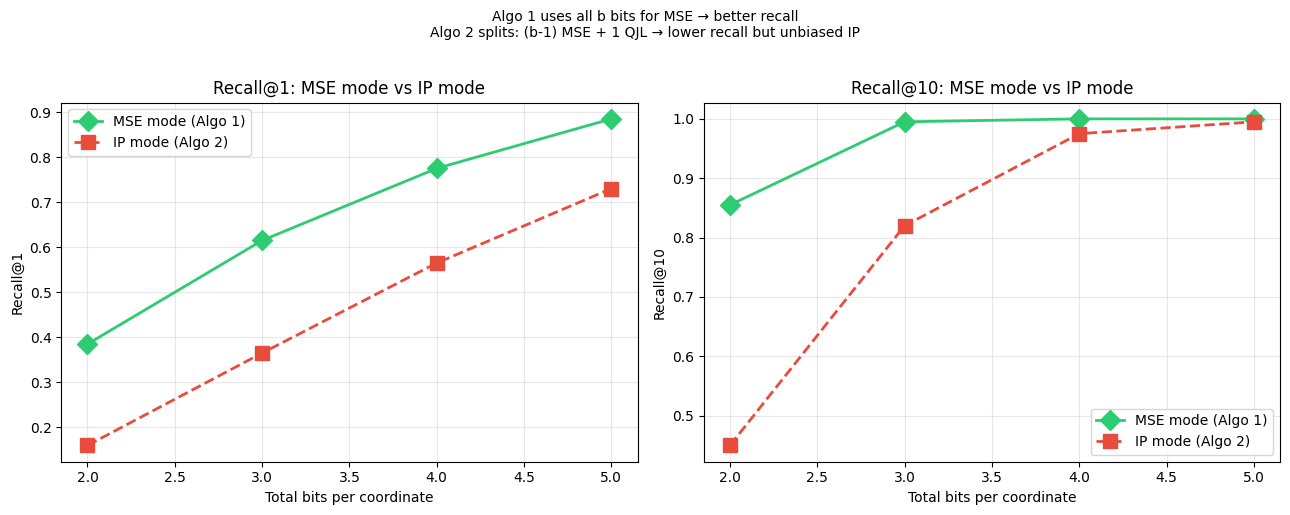

In [23]:
# ── MSE-mode (Algo 1) vs IP-mode (Algo 2) recall comparison ──────────────
db_n = db_raw.copy(); q_n = queries_raw.copy()
db_n /= np.linalg.norm(db_n, axis=1, keepdims=True) + 1e-12
q_n  /= np.linalg.norm(q_n,  axis=1, keepdims=True) + 1e-12

mse_results = []  # (bits, r1_mse, r10_mse, r1_ip, r10_ip)
for bits in [2, 3, 4, 5]:
    # MSE mode (Algorithm 1 — all b bits for MSE)
    idx_mse = TurboQuantIndex(dim=DIM, bits=bits, metric='mse', seed=SEED)
    idx_mse.add(torch.from_numpy(db_n))
    _, ids_mse = idx_mse.search(torch.from_numpy(q_n), k=K)
    r1_mse  = recall_at_k(gt_ids, ids_mse.numpy(), 1)
    r10_mse = recall_at_k(gt_ids, ids_mse.numpy(), K)

    # IP mode (Algorithm 2 — (b-1) bits MSE + 1 bit QJL)
    idx_ip = TurboQuantIndex(dim=DIM, bits=bits, metric='ip', seed=SEED)
    idx_ip.add(torch.from_numpy(db_n))
    _, ids_ip = idx_ip.search(torch.from_numpy(q_n), k=K)
    r1_ip  = recall_at_k(gt_ids, ids_ip.numpy(), 1)
    r10_ip = recall_at_k(gt_ids, ids_ip.numpy(), K)

    mse_results.append((bits, r1_mse, r10_mse, r1_ip, r10_ip))

print(f"{'Bits':>4}  {'R@1 MSE':>8}  {'R@10 MSE':>9}  {'R@1 IP':>7}  {'R@10 IP':>8}  {'MSE bits':>9}  {'IP: MSE+QJL':>12}")
print("-" * 70)
for b, r1m, r10m, r1i, r10i in mse_results:
    print(f"{b:>4}  {r1m:>8.3f}  {r10m:>9.3f}  {r1i:>7.3f}  {r10i:>8.3f}  {b:>6}b MSE  {b-1}b MSE + 1b QJL")

# ── Plot ──────────────────────────────────────────────────────────────────
bits_list = [r[0] for r in mse_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(bits_list, [r[1] for r in mse_results], 'D-', color='#2ecc71', lw=2, ms=10, label='MSE mode (Algo 1)')
ax1.plot(bits_list, [r[3] for r in mse_results], 's--', color='#e74c3c', lw=2, ms=10, label='IP mode (Algo 2)')
ax1.set_xlabel('Total bits per coordinate')
ax1.set_ylabel('Recall@1')
ax1.set_title('Recall@1: MSE mode vs IP mode')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(bits_list, [r[2] for r in mse_results], 'D-', color='#2ecc71', lw=2, ms=10, label='MSE mode (Algo 1)')
ax2.plot(bits_list, [r[4] for r in mse_results], 's--', color='#e74c3c', lw=2, ms=10, label='IP mode (Algo 2)')
ax2.set_xlabel('Total bits per coordinate')
ax2.set_ylabel('Recall@10')
ax2.set_title('Recall@10: MSE mode vs IP mode')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Algo 1 uses all b bits for MSE → better recall\nAlgo 2 splits: (b-1) MSE + 1 QJL → lower recall but unbiased IP', 
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('mse_vs_ip_recall.png', dpi=150)
plt.show()

## 5 · Recall vs Memory (Pareto Plot)

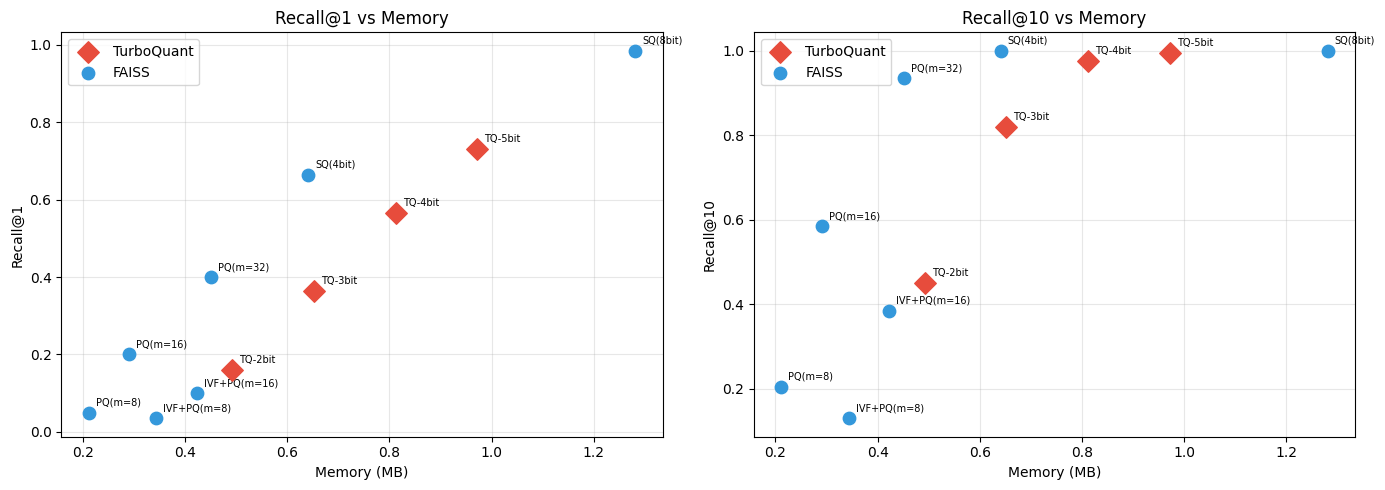

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate TQ vs FAISS
tq   = [r for r in results if r[0].startswith('TQ')]
faiss_r = [r for r in results if not r[0].startswith('TQ')]

for ax, metric_idx, label in [(axes[0], 4, 'Recall@1'), (axes[1], 5, 'Recall@10')]:
    ax.scatter([r[3] for r in tq],      [r[metric_idx] for r in tq],
              s=120, marker='D', color='#e74c3c', zorder=5, label='TurboQuant')
    ax.scatter([r[3] for r in faiss_r],  [r[metric_idx] for r in faiss_r],
              s=80,  marker='o', color='#3498db', zorder=4, label='FAISS')
    for r in results:
        ax.annotate(r[0], (r[3], r[metric_idx]), fontsize=7,
                    textcoords='offset points', xytext=(5, 5))
    ax.set_xlabel('Memory (MB)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Memory')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_recall_vs_memory.png', dpi=150)
plt.show()

## 6 · Index Time Comparison (Bar Chart)

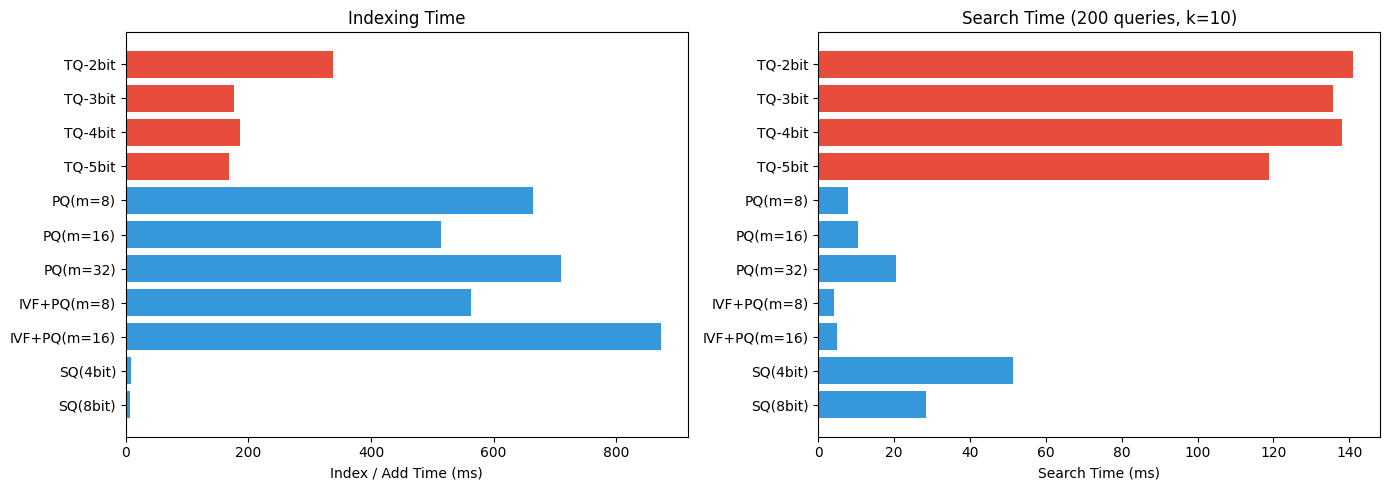

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = [r[0] for r in results]
colors = ['#e74c3c' if n.startswith('TQ') else '#3498db' for n in names]

# Add time
ax1.barh(names, [r[1] for r in results], color=colors)
ax1.set_xlabel('Index / Add Time (ms)')
ax1.set_title('Indexing Time')
ax1.invert_yaxis()

# Search time
ax2.barh(names, [r[2] for r in results], color=colors)
ax2.set_xlabel('Search Time (ms)')
ax2.set_title(f'Search Time ({N_QUERIES} queries, k={K})')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('timing_comparison.png', dpi=150)
plt.show()

## 7 · Recall vs Bits (TurboQuant Scaling)

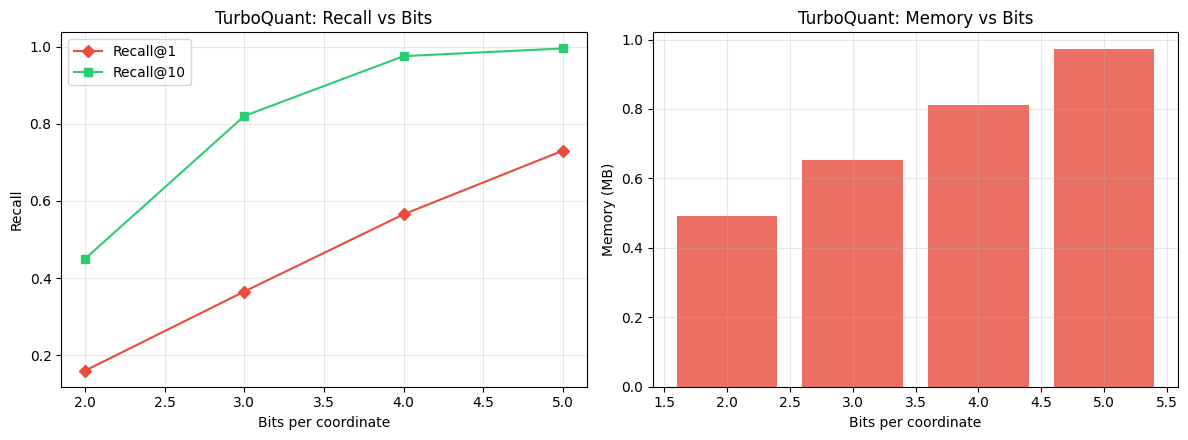

In [26]:
tq_bits  = [int(r[0].split('-')[1][0]) for r in tq]
tq_r1    = [r[4] for r in tq]
tq_r10   = [r[5] for r in tq]
tq_mem   = [r[3] for r in tq]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(tq_bits, tq_r1,  'D-', color='#e74c3c', label='Recall@1')
ax1.plot(tq_bits, tq_r10, 's-', color='#2ecc71', label='Recall@10')
ax1.set_xlabel('Bits per coordinate')
ax1.set_ylabel('Recall')
ax1.set_title('TurboQuant: Recall vs Bits')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(tq_bits, tq_mem, color='#e74c3c', alpha=0.8)
ax2.set_xlabel('Bits per coordinate')
ax2.set_ylabel('Memory (MB)')
ax2.set_title('TurboQuant: Memory vs Bits')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('turboquant_scaling.png', dpi=150)
plt.show()

## Key Takeaways

| Aspect | TurboQuant | FAISS PQ/SQ |
|--------|-----------|-------------|
| **Training** | None (rotation is data-independent) | Requires training on data |
| **Index time** | Very fast (single matrix multiply) | Slower (k-means clustering) |
| **Memory** | Configurable via bits (1-8 per coord) | Configurable via m, bits |
| **Recall** | Competitive at matched memory | Highly optimized |
| **GPU support** | Native PyTorch | Separate faiss-gpu build |

### MSE vs Recall — The Key Distinction

The paper's "~2.7x of Shannon" refers to **reconstruction MSE**, not recall:
- **MSE** = how close the reconstructed vector is to the original (TurboQuant is near-optimal here)
- **Recall** = whether the true neighbor lands in the top-k results (depends on distance **ranking**, not absolute error)
- **Algorithm 2 (IP mode)** splits the bit budget: $(b{-}1)$ bits MSE + 1 bit QJL — at 3 bits total, only 2 bits go to MSE
- At small $d$ (128) with random data, distances concentrate → even small errors shuffle rankings
- At production dimensions ($d \geq 384$), the gap shrinks significantly